In [1]:
import pandas as pd
import numpy as np

# Đọc file dataset
df = pd.read_csv('data.csv', encoding='ISO-8859-1')

# Kiểm tra tổng quan kích thước và thông tin ban đầu
print(f"Kích thước ban đầu: {df.shape[0]} dòng, {df.shape[1]} cột")
df.info()

Kích thước ban đầu: 541909 dòng, 8 cột
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [2]:
# Loại bỏ dòng thiếu CustomerID
df_clean = df.dropna(subset=['CustomerID']).copy()

# Chuyển CustomerID về kiểu số nguyên
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

print(f"Số dòng sau khi lọc thiếu CustomerID: {df_clean.shape[0]}")

Số dòng sau khi lọc thiếu CustomerID: 406829


In [3]:
# 1. Loại bỏ các hóa đơn bắt đầu bằng ký tự 'C'
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# 2. Chỉ giữ lại số lượng mua thực tế (Quantity > 0)
df_clean = df_clean[df_clean['Quantity'] > 0]

# 3. Chỉ giữ lại đơn giá hợp lệ (UnitPrice > 0)
df_clean = df_clean[df_clean['UnitPrice'] > 0]

print(f"Số dòng sau khi lọc giao dịch hợp lệ: {df_clean.shape[0]}")

Số dòng sau khi lọc giao dịch hợp lệ: 397884


In [4]:
# Chuyển đổi định dạng ngày giờ
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Tạo cột tổng chi tiêu cho từng dòng sản phẩm
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Xem 5 dòng dữ liệu hoàn chỉnh
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [5]:

# 1. Xác định ngày Snapshot (ngày giao dịch cuối cùng + 1 ngày)
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Mốc thời gian phân tích (Snapshot Date): {snapshot_date}")

# 2. Tổng hợp bảng chỉ số RFM
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
}).reset_index()

# 3. Đổi tên cột cho rõ nghĩa
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalAmount': 'Monetary'
}, inplace=True)

# 4. Kiểm tra 5 dòng đầu tiên và thống kê mô tả
print("\n--- 5 DÒNG ĐẦU TIÊN CỦA BẢNG RFM ---")
print(rfm.head())

print("\n--- BẢNG THỐNG KÊ MÔ TẢ CÁC CHỈ SỐ RFM ---")
print(rfm.describe().round(2))

Mốc thời gian phân tích (Snapshot Date): 2011-12-10 12:50:00

--- 5 DÒNG ĐẦU TIÊN CỦA BẢNG RFM ---
   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        2          7   4310.00
2       12348       75          4   1797.24
3       12349       19          1   1757.55
4       12350      310          1    334.40

--- BẢNG THỐNG KÊ MÔ TẢ CÁC CHỈ SỐ RFM ---
       CustomerID  Recency  Frequency   Monetary
count     4338.00  4338.00    4338.00    4338.00
mean     15300.41    92.54       4.27    2054.27
std       1721.81   100.01       7.70    8989.23
min      12346.00     1.00       1.00       3.75
25%      13813.25    18.00       1.00     307.41
50%      15299.50    51.00       2.00     674.48
75%      16778.75   142.00       5.00    1661.74
max      18287.00   374.00     209.00  280206.02


In [6]:

from sklearn.preprocessing import StandardScaler

# 1. Biến đổi Log để giảm độ lệch
rfm_log = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']])

# 2. Chuẩn hóa tỷ lệ đưa về cùng thang đo (Z-score)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# Chuyển thành DataFrame để tiện theo dõi
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
rfm_scaled_df.head()

,Recency,Frequency,Monetary
0,1.461993,-0.955214,3.706225
1,-2.038734,1.074425,1.411843
2,0.373104,0.386304,0.716489
3,-0.623086,-0.955214,0.698739
4,1.424558,-0.955214,-0.618962


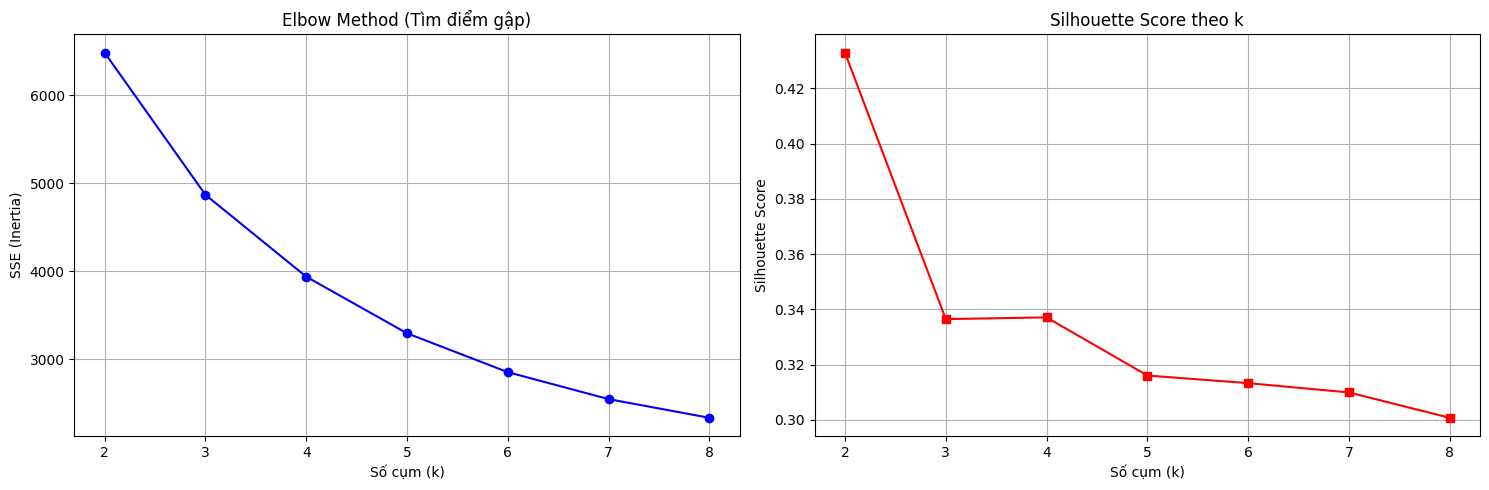

In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

sse = {}
silhouette_scores = {}

# Thử nghiệm từ k = 2 đến 8
for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    sse[k] = kmeans.inertia_
    silhouette_scores[k] = silhouette_score(rfm_scaled, kmeans.labels_)

# Vẽ biểu đồ Elbow và Silhouette
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Biểu đồ Elbow
ax[0].plot(list(sse.keys()), list(sse.values()), marker='o', color='b')
ax[0].set_title('Elbow Method (Tìm điểm gập)')
ax[0].set_xlabel('Số cụm (k)')
ax[0].set_ylabel('SSE (Inertia)')
ax[0].grid(True)

# Biểu đồ Silhouette Score
ax[1].plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker='s', color='r')
ax[1].set_title('Silhouette Score theo k')
ax[1].set_xlabel('Số cụm (k)')
ax[1].set_ylabel('Silhouette Score')
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [8]:
# Huấn luyện K-Means với k = 4
kmeans_model = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_model.fit_predict(rfm_scaled)

# Kiểm tra số lượng khách hàng trong từng cụm
print("Số lượng khách hàng mỗi cụm:")
print(rfm['Cluster'].value_counts().sort_index())

Số lượng khách hàng mỗi cụm:
Cluster
0     837
1     716
2    1173
3    1612
Name: count, dtype: int64


In [9]:
# Tổng hợp các chỉ số trung bình theo từng Cụm
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

print(cluster_summary)

        Recency Frequency Monetary      
           mean      mean     mean count
Cluster                                 
0         18.12      2.15   551.82   837
1         12.13     13.71  8074.27   716
2         71.08      4.08  1802.83  1173
3        182.50      1.32   343.45  1612


In [10]:
from google.colab import files
import numpy as np
import pandas as pd

# 1. Gán nhãn phân khúc mang ý nghĩa kinh doanh
cluster_mapping = {
    1: 'VIP / Champions',
    2: 'Potential Loyalists',
    0: 'Recent / New Customers',
    3: 'At Risk / Hibernating',
}
rfm['Segment'] = rfm['Cluster'].map(cluster_mapping)

# 2. Tổng hợp chỉ số kinh doanh theo từng phân khúc
segment_analysis = (
    rfm.groupby('Segment')
    .agg(
        Customer_Count=('CustomerID', 'count'),
        Total_Revenue=('Monetary', 'sum'),
        Avg_Recency=('Recency', 'mean'),
        Avg_Frequency=('Frequency', 'mean'),
        Avg_Monetary=('Monetary', 'mean'),
    )
    .reset_index()
)

# 3. Tính tỷ trọng % khách hàng và % doanh thu
segment_analysis['Customer_Share_%'] = (
    segment_analysis['Customer_Count'] / rfm['CustomerID'].nunique()
) * 100
segment_analysis['Revenue_Share_%'] = (
    segment_analysis['Total_Revenue'] / rfm['Monetary'].sum()
) * 100

# Sắp xếp theo thứ tự doanh thu giảm dần và hiển thị
segment_analysis = segment_analysis.sort_values(
    by='Total_Revenue', ascending=False
)
print(segment_analysis.round(2).to_string(index=False))

# 4. Xuất file CSV và tải tự động về máy tính
file_name = 'rfm_segmented_customers.csv'
rfm.to_csv(file_name, index=False)
print(f"\n--> Đang tải file '{file_name}' về máy...")

# Lệnh kích hoạt tải file về máy từ Google Colab
files.download(file_name)

               Segment  Customer_Count  Total_Revenue  Avg_Recency  Avg_Frequency  Avg_Monetary  Customer_Share_%  Revenue_Share_%
       VIP / Champions             716     5781175.08        12.13          13.71       8074.27             16.51            64.87
   Potential Loyalists            1173     2114718.42        71.08           4.08       1802.83             27.04            23.73
 At Risk / Hibernating            1612      553641.45       182.50           1.32        343.45             37.16             6.21
Recent / New Customers             837      461872.95        18.12           2.15        551.82             19.29             5.18

--> Đang tải file 'rfm_segmented_customers.csv' về máy...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
import pandas as pd
from google.colab import files

# Đọc file rfm đã phân cụm
rfm = pd.read_csv('rfm_segmented_customers.csv')

# Làm tròn Monetary về số nguyên nguyên bản (integer) để Power BI không bị nhầm dấu chấm/phẩy
rfm['Monetary'] = rfm['Monetary'].round(0).astype(int)

# Xuất file mới
new_file_name = 'rfm_clean_for_pbi.csv'
rfm.to_csv(new_file_name, index=False)

# Tải về máy
files.download(new_file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>